# N11 — Memória Reflexiva

* Professor: Julio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>


## 0.1 Pré-requisitos

Para acompanhar este notebook, é esperado que você já tenha:

- concluído o sobre Memória em LangGraph, principalmente as seções de `store`, `SqliteStore` e `namespace`;
- noções de ciclos em LangGraph (gerar → avaliar → revisar);
- noções básicas de vetores e similaridade (não é necessário conhecer a fundo, vamos construir isso do zero).


## 0.2 Objetivos

Ao final deste notebook, você deverá saber:

1. Explicar por que memória "crua" (listar tudo que foi salvo) não escala.
2. Diferenciar os dois componentes da memória reflexiva: recuperação seletiva e autocrítica.
3. Implementar busca semântica sobre um `store`, do zero, com embeddings simples (TF-IDF) e similaridade de cosseno.
4. Analisar um caso real (dataset ARC Challenge respondido por um modelo pequeno) em que memória reflexiva muda o resultado — para melhor e para pior.
5. Construir um agente em LangGraph que recupera lições relevantes, responde, se autoavalia e grava novas lições quando erra.
6. Reconhecer os limites da memória reflexiva (ruído, poluição, necessidade de poda).


## 0.3 Mapa do notebook

Neste notebook, vamos construir progressivamente:

1. Por que memória "crua" não basta.
2. O que é memória reflexiva: recuperação seletiva + autocrítica.
3. Busca semântica sobre o `store`, feita do zero.
4. Estudo de caso real: ARC Challenge com e sem memória reflexiva.
5. Um agente reflexivo completo em LangGraph.
6. A memória crescendo com o uso, ao longo de várias perguntas.
7. Cuidados e limites da memória reflexiva.


## 0.4 Contexto usado nos exemplos

Este notebook combina dois cenários:

- o **curso de LangGraph** dos notebooks anteriores (alunos como Renan e Ana), usado para construir o agente reflexivo passo a passo;
- um **estudo de caso real**: um recorte de 22 questões de ciências do dataset **ARC Challenge**, respondidas por um modelo pequeno (phi-2) com e sem contexto de raciocínios recuperados por similaridade semântica.

O recorte já vem embutido no próprio notebook (seção 4) — você não precisa baixar nem anexar nenhum arquivo externo para rodar esta aula.

---

## 0.5 Preparação do ambiente

Além do que já usamos no Notebook 5, vamos precisar de uma forma simples de gerar embeddings. Para manter o notebook 100% executável sem depender de chave de API paga, usamos `scikit-learn` (TF-IDF) — suficiente para os exemplos didáticos desta aula.

In [1]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
%pip install -U langgraph langchain langchain-ollama langgraph-checkpoint-sqlite scikit-learn numpy pydantic


  Using cached langgraph_checkpoint_sqlite-3.1.1-py3-none-any.whl.metadata (5.1 kB)
  Using cached aiosqlite-0.22.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached sqlite_vec-0.1.9-py3-none-win_amd64.whl.metadata (198 bytes)
Using cached langgraph_checkpoint_sqlite-3.1.1-py3-none-any.whl (40 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB 9.3 MB/s eta 0:00:01
   ------- -------------------------------- 1.6/8.3 MB 20.0 MB/s eta 0:00:01
   ----------------- ---------------------- 3.6/8.3 MB 25.8 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 31.8 MB/s eta 0:00:01
   ---------------------------------- ----- 7.0/8.3 MB 32.1 MB/s eta 0:00:01
   ---------------------------------------  8.3/8.3 MB 33.0 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 29.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ----- ---------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
together 1.5.2 requires rich<14.0.0,>=13.8.1, but you have rich 15.0.0 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Agora importamos os elementos que serão usados ao longo da aula.

In [2]:
import json
import sqlite3
import os
import uuid
from dataclasses import dataclass
from typing import Annotated, Literal, TypedDict

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.runtime import Runtime

from langgraph.store.sqlite import SqliteStore
from langgraph.store.base import BaseStore


Os imports novos em relação aos outros notebooks são:

- `numpy` e `sklearn.feature_extraction.text.TfidfVectorizer`: para gerar embeddings simples de texto.
- `pydantic.BaseModel`/`Field`: para saída estruturada do avaliador (mesmo padrão do Notebook 3).


Funções auxiliares de exibição — as mesmas dos notebooks anteriores.

In [3]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display, Markdown


def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


def print_last_message(result: dict) -> None:
    display(Markdown(result["messages"][-1].content))


Inicializamos o modelo, seguindo o mesmo processo dos notebooks anteriores.

In [5]:
# Reaproveite aqui a mesma configuração de LLM usada nos notebooks anteriores.
#llm = init_chat_model("ollama:llama3.2:3b", temperature=0)

from dotenv import load_dotenv

load_dotenv()
print("Chave OPENAI_API_KEY configurada com sucesso." if "OPENAI_API_KEY" in os.environ else "Chave não encontrada.")

llm = init_chat_model("openai:gpt-4o-mini", temperature=0)


Chave OPENAI_API_KEY configurada com sucesso.


---

# 1. Por que memória "crua" não basta

Estudamos que o `store` guarda episódios e podemos recuperar **todos** eles com `store.search(namespace)`. 

Isso funciona com poucos registros, mas não escala: conforme a memória cresce, listar tudo significa jogar informação irrelevante para dentro do prompt.

Vamos reconstruir o store de episódios do Renan (já com a correção de `isolation_level=None`) e simular um cenário mais realista, com uma quantidade maior de informação salva.

In [6]:
conexao_store = sqlite3.connect(
    "memoria_reflexiva.db",
    check_same_thread=False,
    isolation_level=None,  # necessário: o SqliteStore controla suas próprias transações
)
store = SqliteStore(conexao_store)
store.setup()


In [8]:
episodios_renan = [
    "Perguntou sobre reducers e sobre como funciona o add_messages.",
    "Pediu ajuda para montar um roteador de intenção com LLM.",
    "Quis saber a diferença entre StateGraph e create_agent.",
    "Perguntou como funciona bind_tools e ToolMessage.",
    "Teve dúvida sobre por que usar TypedDict em vez de dict comum.",
    "Perguntou sobre ciclos e critério de parada em grafos.",
    "Quis entender a diferença entre checkpointer e store.",
    "Perguntou como funciona o RunnableConfig e o thread_id.",
]

for resumo in episodios_renan:
    store.put(("episodios", "renan"), str(uuid.uuid4()), {"resumo": resumo})

print(f"{len(episodios_renan)} episódios salvos para o Renan.")


8 episódios salvos para o Renan.


Agora o Renan faz uma pergunta nova sobre `Runtime` e `Context`. Se listarmos tudo com `search`, o que volta?

In [9]:
for item in store.search(("episodios", "renan")):
    print("-", item.value["resumo"])


- Perguntou sobre reducers e sobre como funciona o add_messages.
- Pediu ajuda para montar um roteador de intenção com LLM.
- Quis saber a diferença entre StateGraph e create_agent.
- Perguntou como funciona bind_tools e ToolMessage.
- Teve dúvida sobre por que usar TypedDict em vez de dict comum.
- Perguntou sobre ciclos e critério de parada em grafos.
- Quis entender a diferença entre checkpointer e store.
- Perguntou como funciona o RunnableConfig e o thread_id.
- Pediu ajuda para montar um roteador de intenção com LLM.
- Quis saber a diferença entre StateGraph e create_agent.


## 1.1 O problema

A pergunta do Renan é sobre `Runtime`/`Context`. 

Apenas **um** dos oito episódios é claramente relacionado (`RunnableConfig`/`thread_id`) — mas `search(namespace)` devolve **todos** os oito, sem ordenar por relevância. 

Se colocássemos tudo isso no prompt do LLM:

- gastamos tokens com conteúdo irrelevante (reducers, ciclos, bind_tools);
- diluímos a atenção do modelo no que realmente importa;
- em memórias com centenas de episódios, isso se torna inviável.

É exatamente esse problema que a **memória reflexiva** ataca.


---

# 2. O que é memória reflexiva

Memória reflexiva combina duas ideias:

```text
(a) Recuperação seletiva  → buscar, por similaridade, só o que é relevante agora
(b) Autocrítica            → quando o agente erra, gerar uma "lição aprendida" (resultado de uma reflexão) e guardá-la
```

**(a) Recuperação seletiva.** Em vez de listar tudo que está no store, calculamos o quão parecida cada memória é da pergunta atual, e trazemos só as mais relevantes (as *top-k*). É o que o campo `retrieval_stats.avg_similarity` do arquivo `reflection_test.json` está registrando — veremos isso na prática na seção 4.

**(b) Autocrítica.** O agente não só responde: ele também se avalia. Quando a resposta é considerada fraca, o agente gera uma lição curta ("da próxima vez, lembrar de X") e grava essa lição no store, para que perguntas **futuras e diferentes** se beneficiem dela. É a mesma lógica do ciclo ``gerar → avaliar → revisar'' que estudamos, mas agora persistida — a revisão não se perde no fim da execução, ela vira memória de longo prazo.

Nas próximas seções, construímos cada peça separadamente antes de juntar tudo em um grafo.


---

# 3. Busca semântica no Store, do zero

## 3.1 Gerando embeddings de forma trivial

Um embedding é só um vetor de números que representa um texto, de forma que textos parecidos gerem vetores parecidos. Não precisamos de um modelo sofisticado para ilustrar o conceito: `TfidfVectorizer` conta a importância de cada palavra em um conjunto de textos e gera um vetor por texto — o suficiente para comparar similaridade de tópico.

In [15]:
def gerar_embeddings(textos: list[str]) -> np.ndarray:
    """Transforma uma lista de textos em uma matriz de vetores TF-IDF."""
    vectorizer = TfidfVectorizer()
    matriz = vectorizer.fit_transform(textos)
    return matriz.toarray()


## 3.2 Similaridade de cosseno, à mão

Similaridade de cosseno mede o ângulo entre dois vetores: quanto mais próximos de 0 graus (vetores "apontando" para o mesmo lugar), mais parecidos os textos.

```text
similaridade(a, b) = (a · b) / (||a|| * ||b||)
```

In [16]:
def similaridade_cosseno(vetor_a: np.ndarray, vetor_b: np.ndarray) -> float:
    norma_a = np.linalg.norm(vetor_a)
    norma_b = np.linalg.norm(vetor_b)
    if norma_a == 0 or norma_b == 0:
        return 0.0
    return float(np.dot(vetor_a, vetor_b) / (norma_a * norma_b))


## 3.3 Recuperando os *k* itens mais relevantes de um namespace

Juntamos os dois elementos: buscamos tudo que existe no namespace, geramos embeddings de todos os textos de uma vez (incluindo a pergunta atual), e ordenamos pela similaridade com a pergunta.

In [17]:
def buscar_relevantes(
    store: BaseStore,
    namespace: tuple[str, ...],
    consulta: str,
    campo_texto: str,
    k: int = 3,
) -> list[dict]:
    """Busca os k itens mais relevantes de um namespace, por similaridade de cosseno."""
    itens = list(store.search(namespace))
    if not itens:
        return []

    textos = [item.value[campo_texto] for item in itens]
    matriz = gerar_embeddings([consulta, *textos])

    vetor_consulta = matriz[0]
    vetores_itens = matriz[1:]

    pontuados = [
        (similaridade_cosseno(vetor_consulta, vetor_item), item)
        for vetor_item, item in zip(vetores_itens, itens)
    ]
    pontuados.sort(key=lambda par: par[0], reverse=True)

    return [
        {"similaridade": similaridade, "valor": item.value}
        for similaridade, item in pontuados[:k]
    ]


Testando com a pergunta do Renan sobre `Runtime`/`Context`:

In [18]:
resultados = buscar_relevantes(
    store,
    ("episodios", "renan"),
    consulta="O que é Runtime e Context em LangGraph?",
    campo_texto="resumo",
    k=3,
)

for r in resultados:
    print(f"[{r['similaridade']:.2f}] {r['valor']['resumo']}")


[0.19] Teve dúvida sobre por que usar TypedDict em vez de dict comum.
[0.11] Perguntou sobre ciclos e critério de parada em grafos.
[0.00] Perguntou sobre reducers e sobre como funciona o add_messages.


## Discussão

Agora, em vez de recuperar todos os oito episódios, a solução retorna só os três ``mais parecidos'' (similares) com a pergunta atual — e o episódio sobre `RunnableConfig`/`thread_id` deve aparecer entre os primeiros, com maior similaridade.

`TfidfVectorizer` é propositalmente simples: ele compara palavras, não significado profundo (não entende sinônimos, por exemplo). 

Em produção, o mesmo papel é feito por embeddings de um modelo de linguagem (ex.: `OpenAIEmbeddings`), que capturam significado, não só vocabulário — mas a lógica de recuperação (gerar vetores, comparar por similaridade, pegar os *top-k*) é exatamente a mesma.


---

# 4. Estudo de caso: ARC Challenge com e sem memória reflexiva

Agora saímos do exemplo didático e olhamos para um caso: um modelo pequeno (phi-2) respondendo questões de ciências do dataset **ARC Challenge**, comparando o desempenho **sem contexto** e **com contexto reflexivo** (exemplos de raciocínio recuperados por similaridade semântica).

Exemplo extraído do contexto da seguinte investigação:

- MOHAMED, A. H.; VILLAS, L. A.; **DOS REIS, J. C.** 2025. [Leveraging LLM Reflection to Improve Small Language Model Agents’ Capabilities.](https://link.springer.com/chapter/10.1007/978-3-032-15632-7_24) In the Proceedings of the 1st International Conference on Agentic and Generative Techniques in Intelligent Computational Systems (AGENTICS). Part of the 17th International Joint Conference on Computational Intelligence (IJCCI’25). Marbella, Spain.

A amostra a seguir tem 22 questões, já rotuladas com a resposta do modelo nos dois cenários — pequeno de propósito, para caber direto no notebook, mas mantendo a mesma proporção de "ajudou/atrapalhou/não mudou" observada no conjunto completo (1172 questões).

## 4.1 O recorte de dados

In [22]:
AMOSTRA_ARC_JSON = '[\n {\n  "index": 129,\n  "pergunta": "Which step in asexual reproduction would you expect to find in volvox but not in amoebas?",\n  "gabarito": "C",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "C",\n   "correta": true,\n   "similaridade_media": 0.539,\n   "exemplos_recuperados": [\n    "Which is true about reproduction for both an amoeba and a paramecium?",\n    "Which phrase does not describe asexual reproduction in organisms?",\n    "Which characteristic does a paramecium have in common with volvox?"\n   ]\n  }\n },\n {\n  "index": 216,\n  "pergunta": "Which activity would help protect the natural habitats of animals?",\n  "gabarito": "D",\n  "sem_contexto": {\n   "resposta": "N/A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": true,\n   "similaridade_media": 0.536,\n   "exemplos_recuperados": [\n    "Which of these animals is most likely to be found living and feeding on the forest floors of Virginia?",\n    "Which of these human activities does not contribute to the extinction of species?",\n    "Which of these is the most likely effect of cutting down large numbers of trees?"\n   ]\n  }\n },\n {\n  "index": 154,\n  "pergunta": "Why does a floor covered with tile feel colder than a floor covered with carpet?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": true,\n   "similaridade_media": 0.395,\n   "exemplos_recuperados": [\n    "A block of ice is placed on a hot sidewalk. The ice melts because",\n    "After a soccer game, Brittany sat under a fan because she was hot. Under the fan, she felt cooler than before. Which explains why Brittany felt cooler under the fan?",\n    "When moist air comes in contact with a cold surface in the winter, one result can be frost. What has happened to the water vapor in the air to cause frost?"\n   ]\n  }\n },\n {\n  "index": 489,\n  "pergunta": "The horizontal axis on a graph is the x-axis. What is most likely placed along this axis?",\n  "gabarito": "D",\n  "sem_contexto": {\n   "resposta": "D",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": true,\n   "similaridade_media": 0.397,\n   "exemplos_recuperados": [\n    "A line graph is best used to",\n    "Which is a true statement regarding the graphing of data?"\n   ]\n  }\n },\n {\n  "index": 52,\n  "pergunta": "Which geologic process most likely caused the formation of the Mount St. Helens Volcano?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": false,\n   "similaridade_media": 0.543,\n   "exemplos_recuperados": [\n    "Most volcanoes develop due to interactions between two tectonic plates. Which of the tectonic plate interactions is least likely to produce volcanic activity?",\n    "An oceanic plate subducts under a continental plate. Which of these landforms most likely results from the interaction of these plates?",\n    "Volcanic eruptions early in Earth\'s history are believed to be responsible for a large proportion of the matter now found in which Earth structure?"\n   ]\n  }\n },\n {\n  "index": 338,\n  "pergunta": "Which of the following sets contains only objects that shine as a result of reflected light?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": false,\n   "similaridade_media": 0.46,\n   "exemplos_recuperados": [\n    "Which of the following is a SOURCE of light?",\n    "Where will a sidewalk feel hottest on a warm, clear day?",\n    "When placed in direct sunlight, which object will absorb the most visible light energy?"\n   ]\n  }\n },\n {\n  "index": 105,\n  "pergunta": "When you have too little water in your body, your kidneys excrete antidiuretic hormone (ADH). What happens in response to ADH?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": false,\n   "similaridade_media": 0.426,\n   "exemplos_recuperados": [\n    "What occurs if the body\'s renal system fails to work?",\n    "Which two systems are involved when waste and water are removed from blood as it flows through the kidneys?",\n    "When people exercise, they often feel thirsty and begin to sweat. It is important for people to feel thirsty when exercising because it makes them realize that they should"\n   ]\n  }\n },\n {\n  "index": 198,\n  "pergunta": "Why is watering plants and grass in the early morning a way to conserve water?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": true,\n   "similaridade_media": 0.557,\n   "exemplos_recuperados": [\n    "Which of these activities is used to conserve water?",\n    "Which of these will most likely increase a plant population in a habitat?",\n    "Many plants tend to wilt on a hot, sunny day. The most likely cause of this wilting is"\n   ]\n  }\n },\n {\n  "index": 877,\n  "pergunta": "What is the first line of defense in the human body against infection and disease?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": true,\n   "similaridade_media": 0.414,\n   "exemplos_recuperados": [\n    "Which structure does a virus have in common with a prokaryotic cell?",\n    "Which action has most helped scientists find cures to some diseases?"\n   ]\n  }\n },\n {\n  "index": 1169,\n  "pergunta": "Which procedure best determines whether water temperature affects the time it will take a sugar cube to dissolve?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": true,\n   "similaridade_media": 0.518,\n   "exemplos_recuperados": [\n    "Sugar is made up of many molecules. When sugar is dissolved in water, what happens to these molecules?",\n    "A small ice cube at a temperature of 0°C is dropped into a glass of water at 28°C and melts. What is the temperature of the water in the glass just after the ice cube melts?",\n    "The temperature of water in a glass changes from 5°C to -1°C. How will the water most likely change?"\n   ]\n  }\n },\n {\n  "index": 878,\n  "pergunta": "Oxygen, hydrogen, and water are substances. Which of these substances are elements?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "N/A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": true,\n   "similaridade_media": 0.578,\n   "exemplos_recuperados": [\n    "What is the most common element found in the compounds that make up ocean water?",\n    "Two elements in the same group on the Periodic Table of the Elements are most similar in their",\n    "Which of these is an element?"\n   ]\n  }\n },\n {\n  "index": 152,\n  "pergunta": "A plateau is most likely formed by",\n  "gabarito": "D",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": true,\n   "similaridade_media": 0.553,\n   "exemplos_recuperados": [\n    "Most mountains on Earth occur in huge ranges stretching for thousands of miles. Which event is most likely to cause the formation of these mountain ranges?",\n    "Which process forced Nevada\'s mountain ranges upward over the past million years?",\n    "What forms both valleys and canyons?"\n   ]\n  }\n },\n {\n  "index": 922,\n  "pergunta": "A student measures the acceleration of a stone block on a level surface when the block is acted upon by a known force. What additional information is needed to precisely calculate the block\'s mass?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": true,\n   "similaridade_media": 0.552,\n   "exemplos_recuperados": [\n    "Which mass is undergoing the greatest amount of acceleration?",\n    "A class is studying the density of rock samples. What scientific equipment do they need to determine the density of the rock samples?",\n    "A student is organizing a room. She moves a box from the floor to a shelf. She wants to estimate the amount of potential energy the box has on the shelf. What information does the student need?"\n   ]\n  }\n },\n {\n  "index": 966,\n  "pergunta": "Missy and Ethan discussed examples of the types of changes in matter. In which example is a chemical change taking place?",\n  "gabarito": "C",\n  "sem_contexto": {\n   "resposta": "C",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": false,\n   "similaridade_media": 0.602,\n   "exemplos_recuperados": [\n    "Emily made a chart that included physical changes and chemical changes. Which change should be categorized as a chemical change?",\n    "Which of the following is an example of a physical change?",\n    "Which activity is an example of a chemical change?"\n   ]\n  }\n },\n {\n  "index": 825,\n  "pergunta": "Dogs and cats are animals that have many similar body structures but they do not mate with each other. These two animals are classified in",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "D",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": true,\n   "similaridade_media": 0.483,\n   "exemplos_recuperados": [\n    "Which animal would most likely stay where it is?",\n    "Tigers and household cats are members of the same family; however, their sizes are vastly different. What is the cause of this difference?",\n    "All organisms classified in kingdom Animalia must also be classified as which of the following?"\n   ]\n  }\n },\n {\n  "index": 189,\n  "pergunta": "Beavers build their homes in ponds and streams. Which characteristic is least critical to building homes in an aquatic environment?",\n  "gabarito": "C",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": false,\n   "similaridade_media": 0.469,\n   "exemplos_recuperados": [\n    "Which of these animals is most likely to be found living and feeding on the forest floors of Virginia?",\n    "Which marine ecosystem is independent of sunlight?",\n    "The body of a fish is covered by scales for"\n   ]\n  }\n },\n {\n  "index": 91,\n  "pergunta": "The stem is an important part of many plants. Which of the following is most similar to the role performed by the stem of a plant?",\n  "gabarito": "D",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": false,\n   "similaridade_media": 0.542,\n   "exemplos_recuperados": [\n    "Which of the following best explains how stems transport water to other parts of the plant?",\n    "Which plant part is similar to a bird\'s egg?",\n    "Plants have cells, tissues, organs, and systems that allow them to function as complete organisms. Which parts of a plant function as an organ?"\n   ]\n  }\n },\n {\n  "index": 760,\n  "pergunta": "When can a student safely start an experiment in a science lab?",\n  "gabarito": "C",\n  "sem_contexto": {\n   "resposta": "C",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": false,\n   "similaridade_media": 0.562,\n   "exemplos_recuperados": [\n    "In order for students to perform lab experiments safely and accurately, they should",\n    "Students are performing an investigation to determine the types of bacteria that grow inside their school. Which activity should the students avoid while performing this investigation?",\n    "Safe practices in the laboratory include all of these except"\n   ]\n  }\n },\n {\n  "index": 352,\n  "pergunta": "Which feature of Great Basin National Park provides the best evidence that glaciers have moved over the landscape?",\n  "gabarito": "D",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": true,\n   "similaridade_media": 0.527,\n   "exemplos_recuperados": [\n    "Which of the following is the best evidence that an area of land was once covered by a glacier?",\n    "As a glacier melts and retreats, a layer of bedrock is exposed. Which term best describes the process that establishes a community on the bedrock?",\n    "Which land form is the result of the constructive force of a glacier?"\n   ]\n  }\n },\n {\n  "index": 677,\n  "pergunta": "Which stage occurs in both the life cycle of a tree and in the life cycle of a frog?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "D",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": false,\n   "similaridade_media": 0.592,\n   "exemplos_recuperados": [\n    "Plant and animal life cycles are alike because they both",\n    "Which term best describes the life cycle of an insect that reaches the adult stage without being a pupa?",\n    "Which event most changes an ecosystem in a single day?"\n   ]\n  }\n },\n {\n  "index": 842,\n  "pergunta": "In October, the constellations Gemini and Orion appear in the sky after midnight. In January, Orion appears at sunset. At which time will Gemini most likely appear in January?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "N/A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "C",\n   "correta": false,\n   "similaridade_media": 0.429,\n   "exemplos_recuperados": [\n    "Stars are organized into patterns called constellations. One constellation is named Leo. Which statement best explains why Leo appears in different areas of the sky throughout the year?",\n    "Which location on Earth has the least intense sunlight on December 22?",\n    "Andy lives in the southern hemisphere. What season does he most likely experience in August?"\n   ]\n  }\n },\n {\n  "index": 142,\n  "pergunta": "Which change in Earth\'s surface is most directly related to the water cycle?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": true,\n   "similaridade_media": 0.592,\n   "exemplos_recuperados": [\n    "Water evaporates and falls back to Earth as rain or snow. What is the primary energy source that drives this cycle?",\n    "What would most likely be measure during an investigation of the water cycle?",\n    "Some water use is consumptive. Instead of returning to its source, the water evaporates from reservoirs or transpires from crops. How does this type of use most likely affect the hydrosphere?"\n   ]\n  }\n }\n]'

amostra_arc = json.loads(AMOSTRA_ARC_JSON)
print(f"{len(amostra_arc)} questões na amostra.")
print(json.dumps(amostra_arc[0], ensure_ascii=False, indent=2))


22 questões na amostra.
{
  "index": 129,
  "pergunta": "Which step in asexual reproduction would you expect to find in volvox but not in amoebas?",
  "gabarito": "C",
  "sem_contexto": {
    "resposta": "A",
    "correta": false
  },
  "com_contexto": {
    "resposta": "C",
    "correta": true,
    "similaridade_media": 0.539,
    "exemplos_recuperados": [
      "Which is true about reproduction for both an amoeba and a paramecium?",
      "Which phrase does not describe asexual reproduction in organisms?",
      "Which characteristic does a paramecium have in common with volvox?"
    ]
  }
}


## 4.2 Acurácia agregada

In [21]:
def acuracia(chave: str) -> float:
    acertos = sum(1 for item in amostra_arc if item[chave]["correta"])
    return acertos / len(amostra_arc)


acc_sem = acuracia("sem_contexto")
acc_com = acuracia("com_contexto")

print(f"Acurácia sem contexto:           {acc_sem:.1%}")
print(f"Acurácia com memória reflexiva:  {acc_com:.1%}")
print(f"Diferença:                       {acc_com - acc_sem:+.1%}")


Acurácia sem contexto:           45.5%
Acurácia com memória reflexiva:  59.1%
Diferença:                       +13.6%


## 4.3 Onde a memória reflexiva ajudou e onde atrapalhou

In [23]:
ajudou = [item for item in amostra_arc if not item["sem_contexto"]["correta"] and item["com_contexto"]["correta"]]
atrapalhou = [item for item in amostra_arc if item["sem_contexto"]["correta"] and not item["com_contexto"]["correta"]]

print(f"Memória reflexiva ajudou em {len(ajudou)} das {len(amostra_arc)} questões do recorte.")
print(f"Memória reflexiva atrapalhou em {len(atrapalhou)} das {len(amostra_arc)} questões do recorte.")


Memória reflexiva ajudou em 8 das 22 questões do recorte.
Memória reflexiva atrapalhou em 5 das 22 questões do recorte.


Um exemplo em que a memória ajudou:

In [24]:
exemplo = ajudou[0]

print("Pergunta:", exemplo["pergunta"])
print("Gabarito:", exemplo["gabarito"])
print()
print("SEM contexto  -> resposta:", exemplo["sem_contexto"]["resposta"], "| correta?", exemplo["sem_contexto"]["correta"])
print("COM contexto  -> resposta:", exemplo["com_contexto"]["resposta"], "| correta?", exemplo["com_contexto"]["correta"])
print("Similaridade média dos exemplos recuperados:", exemplo["com_contexto"]["similaridade_media"])
print("Exemplos recuperados:")
for pergunta_relacionada in exemplo["com_contexto"]["exemplos_recuperados"]:
    print(" -", pergunta_relacionada)


Pergunta: Which step in asexual reproduction would you expect to find in volvox but not in amoebas?
Gabarito: C

SEM contexto  -> resposta: A | correta? False
COM contexto  -> resposta: C | correta? True
Similaridade média dos exemplos recuperados: 0.539
Exemplos recuperados:
 - Which is true about reproduction for both an amoeba and a paramecium?
 - Which phrase does not describe asexual reproduction in organisms?
 - Which characteristic does a paramecium have in common with volvox?


E um exemplo em que a memória **atrapalhou** — importante para não tratar memória reflexiva como solução garantida.

In [25]:
exemplo_ruim = atrapalhou[0]

print("Pergunta:", exemplo_ruim["pergunta"])
print("Gabarito:", exemplo_ruim["gabarito"])
print()
print("SEM contexto  -> resposta:", exemplo_ruim["sem_contexto"]["resposta"], "| correta?", exemplo_ruim["sem_contexto"]["correta"])
print("COM contexto  -> resposta:", exemplo_ruim["com_contexto"]["resposta"], "| correta?", exemplo_ruim["com_contexto"]["correta"])
print("Similaridade média dos exemplos recuperados:", exemplo_ruim["com_contexto"]["similaridade_media"])
print("Exemplos recuperados:")
for pergunta_relacionada in exemplo_ruim["com_contexto"]["exemplos_recuperados"]:
    print(" -", pergunta_relacionada)


Pergunta: Which geologic process most likely caused the formation of the Mount St. Helens Volcano?
Gabarito: A

SEM contexto  -> resposta: A | correta? True
COM contexto  -> resposta: B | correta? False
Similaridade média dos exemplos recuperados: 0.543
Exemplos recuperados:
 - Most volcanoes develop due to interactions between two tectonic plates. Which of the tectonic plate interactions is least likely to produce volcanic activity?
 - An oceanic plate subducts under a continental plate. Which of these landforms most likely results from the interaction of these plates?
 - Volcanic eruptions early in Earth's history are believed to be responsible for a large proportion of the matter now found in which Earth structure?


## 4.4 A similaridade média ajuda a prever quando a memória vai ajudar?

In [26]:
sims_ajudou = [item["com_contexto"]["similaridade_media"] for item in ajudou]
sims_atrapalhou = [item["com_contexto"]["similaridade_media"] for item in atrapalhou]

print(f"Similaridade média — casos em que ajudou:     {np.mean(sims_ajudou):.3f}")
print(f"Similaridade média — casos em que atrapalhou: {np.mean(sims_atrapalhou):.3f}")


Similaridade média — casos em que ajudou:     0.545
Similaridade média — casos em que atrapalhou: 0.519


## Discussão

- A memória reflexiva trouxe um ganho líquido de acurácia no agregado, mas **não foi uniformemente positiva** — ela piorou o resultado em uma fração considerável dos casos.
- Isso reforça que "ter contexto relevante" não é garantia de acerto: o modelo ainda pode se confundir, especialmente se os exemplos recuperados tiverem similaridade só superficial (mesmo vocabulário, raciocínio diferente).
- Compare a similaridade média dos casos em que ajudou vs. atrapalhou: se forem parecidas, significa que `avg_similarity` sozinho não é um bom preditor de qualidade — a métrica de similaridade textual não captura tudo o que importa para o raciocínio.
- Esse tipo de análise é essencial antes de colocar memória reflexiva em produção: sempre medir o efeito líquido, não assumir que "mais contexto" é sempre melhor.


---

# 5. Construindo o pipeline de memória reflexiva em LangGraph

Agora vamos construir, do zero, um agente que:

```text
START
  ↓
retrieve   (busca lições relevantes no store)
  ↓
answer     (responde usando as lições recuperadas)
  ↓
evaluate   (autoavalia a resposta)
  ↓
roteamento condicional
  ├── boa      → END
  └── revisar  → reflect (grava uma lição) → END
```

## 5.1 Contexto e estado do agente

In [27]:
@dataclass
class AlunoContext:
    aluno: str


class AgenteReflexivoState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    licoes_relevantes: list[str]
    avaliacao: Literal["boa", "revisar"]
    feedback: str


## 5.2 Nó `retrieve`

Busca, no namespace `("licoes", aluno)`, as lições mais relevantes para a pergunta atual — reaproveitando `buscar_relevantes` da seção 3.

In [28]:
def retrieve(state: AgenteReflexivoState, runtime: Runtime[AlunoContext]):
    pergunta_atual = state["messages"][-1].content
    aluno = runtime.context.aluno.lower()

    resultados = buscar_relevantes(
        runtime.store,
        ("licoes", aluno),
        consulta=pergunta_atual,
        campo_texto="licao",
        k=3,
    )

    return {"licoes_relevantes": [r["valor"]["licao"] for r in resultados]}


## 5.3 Nó `answer`

Monta um prompt de sistema incluindo as lições recuperadas (se houver) e responde.

In [30]:
def answer(state: AgenteReflexivoState):
    if state["licoes_relevantes"]:
        licoes_texto = "\n".join(f"- {licao}" for licao in state["licoes_relevantes"])
        contexto = f"Lições aprendidas em conversas anteriores que podem ajudar:\n{licoes_texto}"
    else:
        contexto = "Nenhuma lição relevante encontrada para esta pergunta."

    system_prompt = f"""Você é um tutor técnico do curso de LangGraph.

{contexto}

Responda de forma objetiva e correta. Se uma lição anterior for útil, aplique-a."""

    response = llm.invoke([SystemMessage(content=system_prompt), *state["messages"]])
    return {"messages": [response]}


## 5.4 Nó `evaluate`

O próprio agente se autoavalia, com saída estruturada — mesmo padrão do ciclo de revisão do Notebook 3.

In [31]:
class AutoAvaliacao(BaseModel):
    avaliacao: Literal["boa", "revisar"] = Field(
        description="Se a resposta está tecnicamente correta e completa, ou se precisa de revisão."
    )
    feedback: str = Field(
        description="Se 'revisar', explique em uma frase curta o que faltou ou o que estava errado."
    )


def evaluate(state: AgenteReflexivoState):
    pergunta = state["messages"][-2].content
    resposta = state["messages"][-1].content

    avaliador = llm.with_structured_output(AutoAvaliacao)
    resultado = avaliador.invoke([
        SystemMessage(content="""Avalie a resposta abaixo para uma aula técnica de LangGraph.

Critérios: correção técnica, clareza, objetividade."""),
        HumanMessage(content=f"Pergunta: {pergunta}\n\nResposta: {resposta}"),
    ])

    return {"avaliacao": resultado.avaliacao, "feedback": resultado.feedback}


## 5.5 Nó `reflect`

Só executado quando a avaliação é `"revisar"`. Gera uma lição curta e grava no store, associada ao aluno — para beneficiar perguntas **futuras**, não a atual.

In [32]:
def reflect(state: AgenteReflexivoState, runtime: Runtime[AlunoContext]):
    pergunta = state["messages"][-2].content
    aluno = runtime.context.aluno.lower()

    licao = f"Sobre \"{pergunta}\": {state['feedback']}"

    runtime.store.put(
        ("licoes", aluno),
        str(uuid.uuid4()),
        {"licao": licao, "pergunta": pergunta},
    )

    return {}


## 5.6 Função de roteamento e montagem do grafo

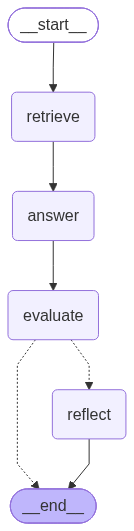

In [33]:
def decidir_apos_avaliacao(state: AgenteReflexivoState) -> Literal["reflect", "__end__"]:
    if state["avaliacao"] == "revisar":
        return "reflect"
    return "__end__"


builder = StateGraph(AgenteReflexivoState, context_schema=AlunoContext)

builder.add_node("retrieve", retrieve)
builder.add_node("answer", answer)
builder.add_node("evaluate", evaluate)
builder.add_node("reflect", reflect)

builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "answer")
builder.add_edge("answer", "evaluate")
builder.add_conditional_edges(
    "evaluate",
    decidir_apos_avaliacao,
    {"reflect": "reflect", "__end__": END},
)
builder.add_edge("reflect", END)

agente_reflexivo = builder.compile(store=store)
display_graph(agente_reflexivo)


---

# 6. Rodando o ciclo: a memória crescendo com o uso

Vamos simular uma sequência de perguntas do Renan. 

Cada `invoke` é uma execução independente do grafo — sem checkpointer, sem `thread_id` — mas todas compartilham o mesmo `store`. 

Se alguma resposta for avaliada como fraca, uma reflexão é elaborada e uma lição é gravada.

Perguntas **futuras** relacionadas podem se beneficiar da lição aprendida armazenada na memória.

In [38]:
perguntas_renan = [
    "O que é um reducer em LangGraph?",
    "Qual é a diferença entre checkpointer e store?",
    "Como funciona o RunnableConfig?",
]

for pergunta in perguntas_renan:
    resultado = agente_reflexivo.invoke(
        {"messages": [HumanMessage(content=pergunta)]},
        context=AlunoContext(aluno="Renan"),
    )
    print("Pergunta:", pergunta)
    print("Lições usadas:", resultado["licoes_relevantes"])
    print("Avaliação:", resultado["avaliacao"], "-", resultado.get("feedback", ""))
    print_last_message(resultado)
    print("-" * 60)


Pergunta: O que é um reducer em LangGraph?
Lições usadas: []
Avaliação: boa - 


Em LangGraph, um reducer é uma função que transforma um estado ou um conjunto de dados em um novo estado, geralmente em resposta a uma ação. Ele é utilizado para gerenciar e atualizar o estado da aplicação de forma previsível, permitindo que você defina como o estado deve mudar em resposta a diferentes ações. Os reducers são uma parte fundamental do padrão de gerenciamento de estado, ajudando a manter a lógica de atualização do estado separada da lógica de apresentação.

------------------------------------------------------------
Pergunta: Qual é a diferença entre checkpointer e store?
Lições usadas: []
Avaliação: boa - 


No contexto de sistemas de gerenciamento de dados e processamento de fluxo, "checkpointer" e "store" têm funções distintas:

1. **Checkpointer**: É um mecanismo que salva o estado atual de um sistema ou aplicação em intervalos regulares. Isso permite que, em caso de falha, o sistema possa ser restaurado a um estado anterior, minimizando a perda de dados. O checkpointer é crucial para garantir a resiliência e a recuperação de sistemas.

2. **Store**: Refere-se a um repositório onde dados são armazenados de forma persistente. Isso pode incluir bancos de dados, sistemas de arquivos ou qualquer outro meio de armazenamento. O objetivo do store é manter os dados disponíveis para acesso e manipulação a longo prazo.

Em resumo, o checkpointer é usado para salvar estados temporários para recuperação, enquanto o store é utilizado para armazenar dados de forma duradoura.

------------------------------------------------------------
Pergunta: Como funciona o RunnableConfig?
Lições usadas: []
Avaliação: boa - 


O `RunnableConfig` é uma classe utilizada no LangGraph para configurar a execução de um runnable, que é uma tarefa ou um conjunto de instruções que podem ser executadas. Ele permite definir parâmetros e opções que influenciam como a tarefa será executada.

Aqui estão alguns pontos principais sobre como funciona o `RunnableConfig`:

1. **Configuração de Parâmetros**: Você pode definir parâmetros que serão passados para o runnable durante a execução. Isso pode incluir variáveis de ambiente, opções de execução, entre outros.

2. **Execução Assíncrona**: O `RunnableConfig` pode ser configurado para permitir a execução assíncrona, o que significa que a tarefa pode ser executada em segundo plano, permitindo que o programa continue a rodar outras operações.

3. **Gerenciamento de Recursos**: Ele pode incluir configurações para gerenciamento de recursos, como limites de memória e tempo de execução, garantindo que a tarefa não consuma mais recursos do que o permitido.

4. **Tratamento de Erros**: O `RunnableConfig` pode incluir opções para tratamento de erros, permitindo que você defina como o sistema deve reagir em caso de falhas durante a execução da tarefa.

Para utilizá-lo, você geralmente cria uma instância do `RunnableConfig`, define as opções desejadas e, em seguida, passa essa configuração para o runnable que você deseja executar.

Se precisar de mais detalhes ou exemplos específicos, sinta-se à vontade para perguntar!

------------------------------------------------------------


Depois de algumas execuções, vamos espiar o que ficou salvo no namespace de lições do Renan.

In [39]:
for item in store.search(("licoes", "renan")):
    print("-", item.value["licao"])


## Discussão

Repare que:

- cada `invoke` é uma execução isolada (não há `thread_id`, não há checkpointer) — mas a memória de longo prazo (`store`) persiste entre elas;
- se a primeira pergunta gerou uma lição, e uma pergunta posterior for suficientemente parecida, `retrieve` deve trazer essa lição de volta;
- isso é diferente do checkpointer do Notebook 5: aqui não estamos lembrando de uma *conversa*, estamos lembrando de *lições* aprendidas ao longo de várias conversas distintas.


---

# 7. Cuidados e limites da memória reflexiva

O estudo de caso da seção 4 já deixou isso claro com números reais, mas vale reforçar:

**Ruído e poluição de memória.** Nem toda lição gravada é boa. Se o avaliador erra (avalia como "revisar" algo que estava certo, ou vice-versa), a lição gravada pode ensinar o agente a fazer a coisa errada no futuro. Memória reflexiva herda os erros do processo de avaliação.

**Similaridade alta não é relevância garantida.** Vimos na seção 4.4 que a similaridade média não separa claramente os casos em que a memória ajudou dos casos em que atrapalhou. Dois textos podem compartilhar vocabulário sem compartilhar raciocínio.

**Memória sem poda cresce para sempre.** Neste notebook, nunca removemos nada do store. Em um sistema real, isso eventualmente:

- deixa a busca mais lenta;
- aumenta a chance de recuperar lições desatualizadas ou contraditórias entre si.

Estratégias comuns para lidar com isso (fora do escopo de implementação desta aula, mas importantes de conhecer):

- **TTL (time-to-live)**: lições expiram depois de um tempo (`SqliteStore` e `PostgresStore` suportam isso nativamente).
- **Deduplicação**: antes de gravar uma lição nova, verificar se já existe uma muito parecida.
- **Poda por uso**: descartar lições que nunca são recuperadas ou que, quando usadas, não melhoram a avaliação.


---

# 8. Exercícios de fixação

## Exercício 1 — Ajustando o `k`

Experimente `k=1` e `k=5` em `buscar_relevantes` na seção 3.3. O que muda na resposta do agente quando poucas ou muitas lições são recuperadas?

## Exercício 2 — Limiar de similaridade

Modifique `buscar_relevantes` para aceitar um parâmetro `limiar: float` e descartar itens com similaridade abaixo dele, mesmo que estejam entre os *top-k*. Teste com um limiar alto (ex.: `0.3`) e veja quando a lista de lições relevantes fica vazia.

## Exercício 3 — Métricas do estudo de caso

Usando os dados da seção 4, calcule a acurácia separadamente para perguntas cujo `retrieval_stats.avg_similarity` está acima e abaixo da mediana. A memória reflexiva funciona melhor quando a similaridade é mais alta?

## Exercício 4 — Deduplicação simples

Antes de `reflect` gravar uma lição nova, adicione uma verificação: se já existir uma lição no namespace do aluno com similaridade acima de `0.8` em relação à nova, não grave (evite lições quase idênticas se acumulando).

## Exercício 5 — Comparando dois alunos

Rode a sequência de perguntas da seção 6 para a Ana, em vez do Renan. Confirme que as lições ficam em namespaces separados (`("licoes", "ana")` vs. `("licoes", "renan")`) e que um aluno não usa lições do outro.

## Exercício 6 — Discussão

Sem escrever código: como você adaptaria o pipeline desta aula para incluir também os **episódios** (resumos de conversas, do Notebook 5) na hora de montar o prompt em `answer`, além das lições? Que cuidado seria necessário para não estourar o tamanho do contexto do modelo?

---

# 9. Síntese

Neste notebook, evoluímos a memória de longo prazo para uma memória **reflexiva**. Os pontos principais foram:

- listar tudo que está salvo em um namespace não escala — é preciso recuperação seletiva;
- construímos busca semântica do zero: embeddings simples (TF-IDF) + similaridade de cosseno + *top-k*;
- um estudo de caso real (ARC Challenge, modelo phi-2) mostrou que memória reflexiva melhora a acurácia agregada, mas não é uniformemente positiva — ela também pode atrapalhar;
- construímos um agente em LangGraph com quatro nós: `retrieve` (busca lições relevantes), `answer` (responde), `evaluate` (autoavalia) e `reflect` (grava lições, só quando necessário);
- a memória gerada por reflexão em uma conversa fica disponível para conversas futuras e diferentes, via `store`;
- memória reflexiva tem limites reais: ruído, poluição, e a necessidade de estratégias de poda em sistemas de produção.


## 9.1 Checklist de compreensão

Antes de seguir, você deve conseguir responder:

1. Qual é a diferença entre recuperação seletiva e autocrítica na memória reflexiva?
2. Por que `search(namespace)` sozinho não é suficiente conforme a memória cresce?
3. Como a similaridade de cosseno é calculada, e o que ela representa intuitivamente?
4. No estudo de caso real, a memória reflexiva ajudou em todos os casos? O que isso implica sobre usar memória reflexiva em produção sem medir o efeito líquido?
5. Por que o nó `reflect` só executa quando a avaliação é `"revisar"`?
6. Cite duas estratégias para evitar que a memória cresça sem controle.


## 9.2 Próximos passos

A partir daqui, os próximos passos naturais são:

- trocar o embedding TF-IDF por embeddings reais de um modelo de linguagem, para capturar significado além de vocabulário;
- combinar memória reflexiva com ferramentas (Notebook 4), permitindo que o agente decida quando consultar fontes externas em vez de (ou além de) memória interna;
- implementar TTL e deduplicação no store, para simular um sistema de memória de produção.


# 10. Referências

- LangGraph — Memory (store): https://docs.langchain.com/oss/python/langgraph/memory
- LangGraph — Persistence: https://docs.langchain.com/oss/python/langgraph/persistence
- Reflexion: Language Agents with Verbal Reinforcement Learning (Shinn et al.): https://arxiv.org/abs/2303.11366
- ARC (AI2 Reasoning Challenge) dataset: https://allenai.org/data/arc
- scikit-learn — TfidfVectorizer: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
- MOHAMED, A. H.; VILLAS, L. A.; **DOS REIS, J. C.** 2025. [Leveraging LLM Reflection to Improve Small Language Model Agents’ Capabilities.](https://link.springer.com/chapter/10.1007/978-3-032-15632-7_24) In the Proceedings of the 1st International Conference on Agentic and Generative Techniques in Intelligent Computational Systems (AGENTICS). Part of the 17th International Joint Conference on Computational Intelligence (IJCCI’25). Marbella, Spain.
